# Support Vector Machines: complete mathematical demo

This notebook is a **full visual and mathematical demo** of Support Vector Machines (SVMs).  
It is designed to connect four ideas in one coherent story:

1. **Geometry**: hyperplanes, distances, margins, and support vectors.
2. **Convex optimization**: the primal problem, the dual problem, and why SVM is a convex program.
3. **Relation to PCA**: both produce important directions in data, but they optimize fundamentally different objectives.
4. **Kernel trick**: nonlinear classification using inner products in a feature space.

The notebook is deliberately written in a way that can be used for self-study, class demo, or lecture notes.


## Roadmap

We will proceed in the following order.

- Start with linearly separable data in two dimensions.
- Derive the signed distance to a hyperplane.
- Define the margin and obtain the hard-margin SVM optimization problem.
- Visualize support vectors and the maximum-margin separator.
- Move to overlapping data and introduce the soft-margin SVM.
- Derive the dual viewpoint and explain why only support vectors matter.
- Compare SVM with PCA on examples where they agree and where they differ sharply.
- Finish with polynomial and radial-basis-function kernels.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# model Support Vector Machine
from sklearn.svm import SVC, LinearSVC
# funkcje do generowania przykładowych zbiorów danych
from sklearn.datasets import make_blobs, make_moons, make_circles
# algorytm PCA (do redukcji wymiarów danych)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# pozwala łączyć kilka kroków przetwarzania danych w jeden pipelin
from sklearn.pipeline import make_pipeline
# funkcja do mierzenia dokładności modelu
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(7)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

    # -1 oznaczamy kółkiem
    # +1 oznaczamy trójkątem
def plot_points(X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots()
    for label, marker in [(-1, 'o'), (1, '^')]:
        ax.scatter(X[y == label, 0], X[y == label, 1], marker=marker, label=f'class {label}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    if title:
        ax.set_title(title)
    ax.legend()
    return ax


def _mesh_from_data(X, padding=1.0, n=400):
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding
        # tworzymy siatkę punktów (meshgrid)
    # potrzebną do narysowania funkcji decyzyjnej
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n), np.linspace(y_min, y_max, n))
    return xx, yy

# Funkcja rysująca granicę decyzyjną modelu SVM
def plot_decision_function(clf, X, y, ax=None, title=None, show_support=True):
    if ax is None:
        fig, ax = plt.subplots()
    plot_points(X, y, ax=ax)
    xx, yy = _mesh_from_data(X)
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    if show_support and hasattr(clf, 'support_vectors_'):
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=180,
                   facecolors='none', edgecolors='k', linewidths=1.5, label='support vectors')
        ax.legend()
    if title:
        ax.set_title(title)
    return ax

# Funkcja licząca podpisaną odległość punktu od hiperpłaszczyzny
def signed_distance(x, w, b):
    return (x @ w + b) / np.linalg.norm(w)

# Funkcja trenująca liniowy model SVM
def fit_linear_svm(X, y, C=1e6):
    # tworzymy model SVM z liniowym kernelem
    clf = SVC(kernel='linear', C=C)
     # uczymy model na danych
    clf.fit(X, y)
    return clf


## 1. Hyperplanes and linear classifiers

A linear classifier in $\mathbb{R}^d$ is determined by a vector $w \in \mathbb{R}^d$ and a scalar $b \in \mathbb{R}$.
Its decision boundary is the hyperplane
(matematyczny zapis linii, gdzie w jest wektorem prostopadłym)
$$
\{x \in \mathbb{R}^d : w^\top x + b = 0\}.
$$

The corresponding prediction rule is

$$
\hat y = \operatorname{sign}(w^\top x + b).
$$

Geometrically:

- $w$ is **normal** to the separating hyperplane.
- $b$ shifts the hyperplane parallel to itself.
- the sign of $w^\top x + b$ tells us on which side of the hyperplane the point lies.
(ze znaku wiemy po której stronie linii jest punkt)
We first visualize many possible separating lines for a simple 2D dataset.


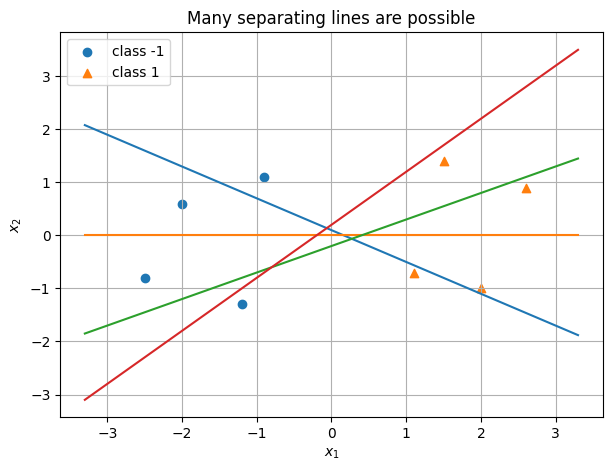

In [2]:
# definiujemy punkty na płaszczyźnie
X_sep = np.array([
    [-2.5, -0.8],
    [-2.0,  0.6],
    [-1.2, -1.3],
    [-0.9,  1.1],
    [ 1.1, -0.7],
    [ 1.5,  1.4],
    [ 2.0, -1.0],
    [ 2.6,  0.9],
])
# oraz do jakiej klasy należą)
y_sep = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

fig, ax = plt.subplots(figsize=(7, 5))
plot_points(X_sep, y_sep, ax=ax, title='Many separating lines are possible')

xx = np.linspace(-3.3, 3.3, 300)
for m, c in [(-0.6, 0.1), (0.0, 0.0), (0.5, -0.2), (1.0, 0.2)]:
    yy = m * xx + c
    ax.plot(xx, yy)

plt.show()


A key question now appears:

> If several hyperplanes separate the data perfectly, which one should we choose?

The SVM answer is: **choose the separator with the largest geometric margin**.


## 2. Signed distance from a point to a hyperplane

For a point $x$, the quantity $w^\top x + b$ does not yet equal a geometric distance because it changes when we rescale $(w,b)$ by a constant factor.

The signed distance from $x$ to the hyperplane $w^\top x + b = 0$ is

$$
\operatorname{dist}_{\pm}(x, H) = \frac{w^\top x + b}{\|w\|}.
$$

The absolute distance is therefore

$$
\operatorname{dist}(x, H) = \frac{|w^\top x + b|}{\|w\|}.
$$

### Why this is true

Write the unit normal vector as

$$
\hat n = \frac{w}{\|w\|}.
$$

Moving by an amount $t$ in the normal direction changes the hyperplane equation by exactly $t\|w\|$, so the orthogonal displacement needed to reach the hyperplane is $(w^\top x+b)/\|w\|$.
(tylko odl -> wartość bezwzgl, ale chcemy wiedzieć po jakiej stronie po normalizacji (dzielenie przez długość wektora, żeby otrzymać prawdziwą odległość)

w = [ 2. -1.], b = -0.5
Point x = [1.2 0.7]
Signed distance = 0.5367


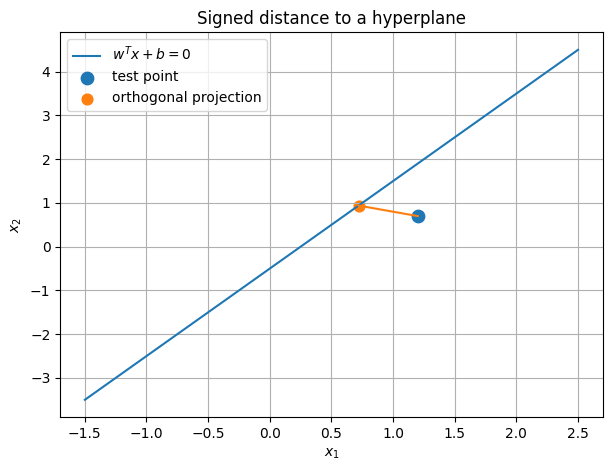

In [3]:
# Demonstrate the signed-distance formula on a concrete line.
w = np.array([2.0, -1.0]) #wektor prostopadły
b = -0.5 #przesunięcie linii
x_test = np.array([1.2, 0.7])

sd = signed_distance(x_test, w, b)
print(f'w = {w}, b = {b}')
print(f'Point x = {x_test}')
print(f'Signed distance = {sd:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
xx = np.linspace(-1.5, 2.5, 300)
yy = (w[0] * xx + b) / (-w[1])
ax.plot(xx, yy, label='$w^T x + b = 0$')
ax.scatter([x_test[0]], [x_test[1]], s=80, label='test point')

# Orthogonal projection onto the line
projection = x_test - sd * w / np.linalg.norm(w)
ax.plot([x_test[0], projection[0]], [x_test[1], projection[1]])
ax.scatter([projection[0]], [projection[1]], s=60, label='orthogonal projection')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Signed distance to a hyperplane')
ax.legend()
plt.show()


## 3. Margin and the hard-margin SVM

Suppose the labels are $y_i \in \{-1,+1\}$ and the data are linearly separable. A classifier is correct on every training point if

$$
y_i(w^\top x_i + b) > 0 \qquad \text{for all } i.
$$

Because scaling $(w,b)$ does not change the separating hyperplane, we are free to normalize them so that the closest points satisfy

$$
y_i(w^\top x_i + b) \ge 1.
$$

(Tu się dzieje coś dziwnego - znajdujemy punkty na krawędzi marginesu, mamy warunki dla nich)

The two margin boundaries are then

$$
w^\top x + b = 1
\qquad \text{and} \qquad
w^\top x + b = -1.
$$

The distance between these two parallel hyperplanes is

$$
\frac{2}{\|w\|}.
$$

So maximizing the margin is equivalent to minimizing $\|w\|$, or more conveniently minimizing $\tfrac12\|w\|^2$.

This gives the **hard-margin SVM** primal problem:

$$
\min_{w,b} \frac12 \|w\|^2
\qquad
\text{subject to}
\qquad
y_i(w^\top x_i + b) \ge 1 \; \text{for all } i.
$$

This is a **convex optimization problem** because:

- the objective is a convex quadratic function,
- the constraints are affine inequalities.


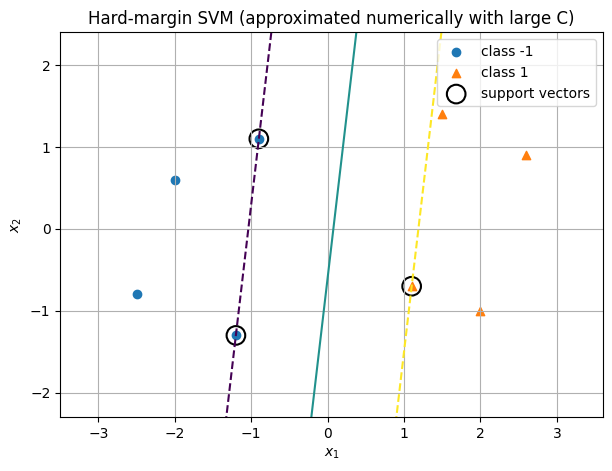

w = [ 0.8986 -0.1127]
b = -0.0676
Margin width = 2 / ||w|| = 2.2085


In [4]:
clf_hard = fit_linear_svm(X_sep, y_sep, C=1e6)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_function(clf_hard, X_sep, y_sep, ax=ax, title='Hard-margin SVM (approximated numerically with large C)')
plt.show()

w = clf_hard.coef_[0]
b = clf_hard.intercept_[0]
margin_width = 2 / np.linalg.norm(w)
print('w =', np.round(w, 4))
print('b =', round(float(b), 4))
print(f'Margin width = 2 / ||w|| = {margin_width:.4f}')


### Support vectors

The points that touch the margin are the **support vectors**.  
These are the training points for which equality holds:

$$
y_i(w^\top x_i + b) = 1.
$$

They matter because they are the points that constrain the maximum-margin separator. Points farther away from the margin can often move a little without changing the solution at all.


In [5]:
# Compute functional margins and signed distances for the hard-margin solution.
functional_margins = y_sep * (X_sep @ w + b)
signed_distances = (X_sep @ w + b) / np.linalg.norm(w)

print('Index | label | functional margin y_i(w^T x_i+b) | signed distance')
for i, (yi, fm, sd) in enumerate(zip(y_sep, functional_margins, signed_distances)):
    print(f'{i:5d} | {yi:5d} | {fm:31.6f} | {sd:14.6f}')

print('\nSupport vector indices:', clf_hard.support_)


Index | label | functional margin y_i(w^T x_i+b) | signed distance
    0 |    -1 |                        2.223857 |      -2.455669
    1 |    -1 |                        1.932373 |      -2.133802
    2 |    -1 |                        0.999374 |      -1.103547
    3 |    -1 |                        1.000313 |      -1.104585
    4 |     1 |                        0.999687 |       1.103893
    5 |     1 |                        1.122417 |       1.239416
    6 |     1 |                        1.842204 |       2.034233
    7 |     1 |                        2.167188 |       2.393093

Support vector indices: [2 3 4]


## 4. Dual viewpoint and why SVM is sparse

To derive the dual, introduce nonnegative Lagrange multipliers $\alpha_i \ge 0$ for the constraints.
The Lagrangian is

$$
L(w,b,\alpha) = \frac12\|w\|^2 - \sum_{i=1}^n \alpha_i \bigl(y_i(w^\top x_i + b)-1\bigr).
$$

Setting derivatives with respect to $w$ and $b$ equal to zero gives the stationarity conditions

$$
w = \sum_{i=1}^n \alpha_i y_i x_i,
\qquad
\sum_{i=1}^n \alpha_i y_i = 0.
$$

Substituting this back yields the dual problem

$$
\max_{\alpha \ge 0}
\sum_{i=1}^n \alpha_i - \frac12 \sum_{i,j=1}^n \alpha_i\alpha_j y_i y_j x_i^\top x_j
$$

subject to

$$
\sum_{i=1}^n \alpha_i y_i = 0.
$$

Two major consequences follow.

1. Data enter the dual **only through inner products** $x_i^\top x_j$.
2. The optimal normal vector is a combination of training samples:

$$
 w = \sum_{i=1}^n \alpha_i y_i x_i.
$$

Only points with $\alpha_i > 0$ contribute. These are exactly the support vectors.


In [6]:
# Recover alpha_i y_i from scikit-learn's dual coefficients.
full_yalpha = np.zeros(len(y_sep))
full_yalpha[clf_hard.support_] = clf_hard.dual_coef_.ravel()
full_alpha = np.abs(full_yalpha)

w_from_dual = (full_yalpha[:, None] * X_sep).sum(axis=0)

print('alpha_i values')
for i, a in enumerate(full_alpha):
    print(f'i={i:2d}, alpha_i={a:.6f}')

print('\nDirect primal w      =', np.round(w, 6))
print('Dual reconstruction w =', np.round(w_from_dual, 6))
print('Difference norm       =', np.linalg.norm(w - w_from_dual))


alpha_i values
i= 0, alpha_i=0.000000
i= 1, alpha_i=0.000000
i= 2, alpha_i=0.260671
i= 3, alpha_i=0.149508
i= 4, alpha_i=0.410179
i= 5, alpha_i=0.000000
i= 6, alpha_i=0.000000
i= 7, alpha_i=0.000000

Direct primal w      = [ 0.89856  -0.112711]
Dual reconstruction w = [ 0.89856  -0.112711]
Difference norm       = 1.3877787807814457e-17


This is one of the most beautiful parts of SVM theory:

- the solution is found by a convex quadratic program,
- but the final classifier depends only on a **small subset** of the data.

This sparsity is one reason SVMs became so influential.


## 5. Soft-margin SVM: non-separable data

Real data are often noisy or overlapping, so the hard-margin constraints may be impossible.  
We therefore introduce slack variables $\xi_i \ge 0$ and require

$$
y_i(w^\top x_i + b) \ge 1 - \xi_i.
$$

The **soft-margin SVM** solves

$$
\min_{w,b,\xi} \frac12\|w\|^2 + C\sum_{i=1}^n \xi_i
$$

subject to

$$
y_i(w^\top x_i+b) \ge 1-\xi_i,
\qquad
\xi_i \ge 0.
$$

The parameter $C > 0$ controls the trade-off:

- large $C$: penalize violations strongly,
- small $C$: allow more violations in exchange for a wider margin.

This is equivalent to minimizing the regularized **hinge loss**

$$
\frac12\|w\|^2 + C\sum_{i=1}^n \max\{0, 1-y_i(w^\top x_i+b)\}.
$$


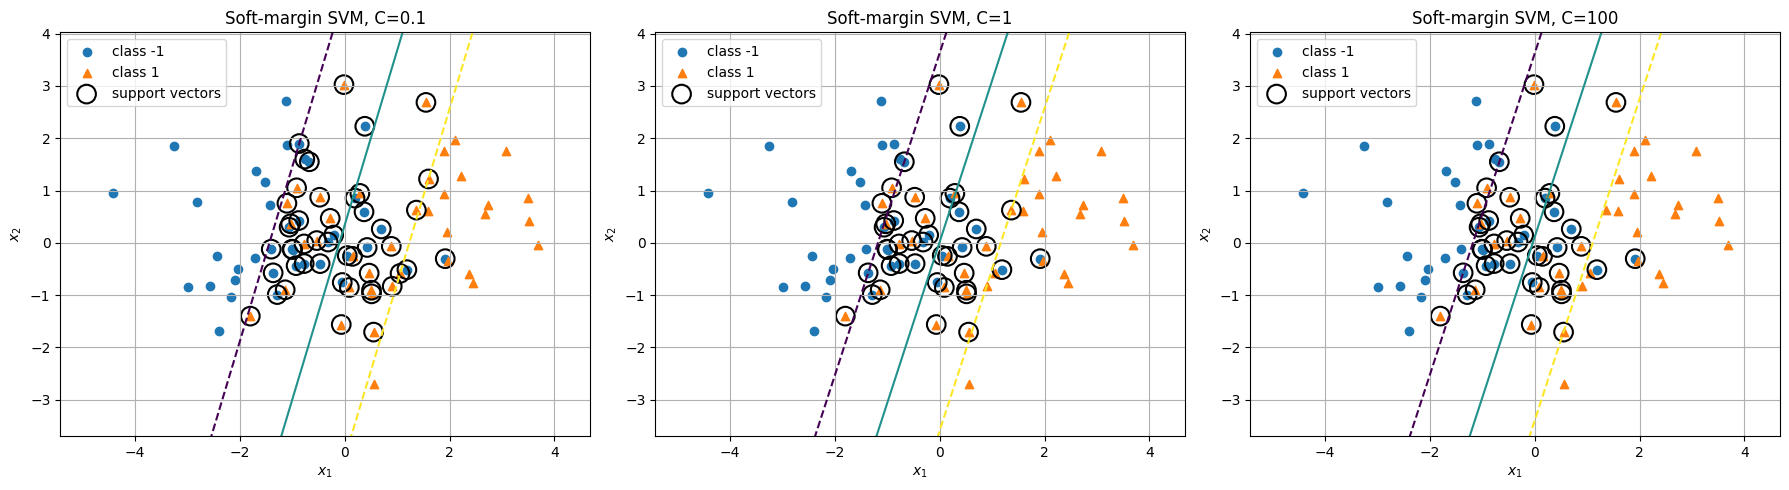

In [7]:
X_soft, y_soft = make_blobs(n_samples=80, centers=[(-1.0, 0.0), (1.0, 0.0)],
                            cluster_std=[1.2, 1.2], random_state=5)
y_soft = 2 * y_soft - 1

Cs = [0.1, 1.0, 100.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, C in zip(axes, Cs):
    clf = fit_linear_svm(X_soft, y_soft, C=C)
    plot_decision_function(clf, X_soft, y_soft, ax=ax, title=f'Soft-margin SVM, C={C:g}')
plt.tight_layout()
plt.show()


In [8]:
for C in Cs:
    clf = fit_linear_svm(X_soft, y_soft, C=C)
    preds = clf.predict(X_soft)
    acc = accuracy_score(y_soft, preds)
    margin = 2 / np.linalg.norm(clf.coef_[0])
    print(f'C={C:>6g} | training accuracy={acc:.3f} | number of support vectors={len(clf.support_):2d} | margin width={margin:.3f}')


C=   0.1 | training accuracy=0.775 | number of support vectors=48 | margin width=2.557
C=     1 | training accuracy=0.775 | number of support vectors=42 | margin width=2.229
C=   100 | training accuracy=0.787 | number of support vectors=41 | margin width=2.173


Observe the qualitative behavior:

- With small $C$, the margin tends to be wider and more points can lie inside the margin or even be misclassified.
- With large $C$, the classifier tries harder to fit the training data.

The optimization problem is still convex, so we keep the major benefit of global optimality.


## 6. PCA versus SVM

PCA and SVM both identify important directions in data, but they optimize **different quantities**.

### PCA objective

Let $S$ be the sample covariance matrix. The first principal component solves

$$
\max_{\|u\|=1} u^\top S u.
$$

So PCA looks for the direction of **largest variance**. It is an **unsupervised** method: labels are ignored.

### SVM objective

The hard-margin SVM solves

$$
\min_{w,b} \frac12\|w\|^2
\quad\text{subject to}\quad
y_i(w^\top x_i+b) \ge 1.
$$

So SVM looks for a direction that gives the **largest separating margin**. It is a **supervised** method: labels are essential.

The two directions may agree, but they do not have to.


In [9]:
def pca_direction(X):
    pca = PCA(n_components=1)
    pca.fit(X)
    return pca.components_[0], pca.mean_


def plot_pca_and_svm(X, y, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots()
    plot_points(X, y, ax=ax)
    pca_dir, center = pca_direction(X)
    clf = fit_linear_svm(X, y, C=1e6)
    svm_normal = clf.coef_[0]

    scale = max(X.std(axis=0)) * 2.5
    ax.arrow(center[0], center[1], scale * pca_dir[0], scale * pca_dir[1],
             length_includes_head=True, head_width=0.15)
    ax.arrow(center[0], center[1], -scale * pca_dir[0], -scale * pca_dir[1],
             length_includes_head=True, head_width=0.15)

    svm_dir = svm_normal / np.linalg.norm(svm_normal)
    ax.arrow(center[0], center[1], scale * svm_dir[0], scale * svm_dir[1],
             length_includes_head=True, head_width=0.15)
    ax.arrow(center[0], center[1], -scale * svm_dir[0], -scale * svm_dir[1],
             length_includes_head=True, head_width=0.15)

    xx = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    yy = -(svm_normal[0] * xx + clf.intercept_[0]) / svm_normal[1]
    ax.plot(xx, yy, linewidth=2)

    if title:
        ax.set_title(title)
    return clf


### Example A: PCA and SVM roughly agree

Here the main variance direction and the separating direction are reasonably aligned.


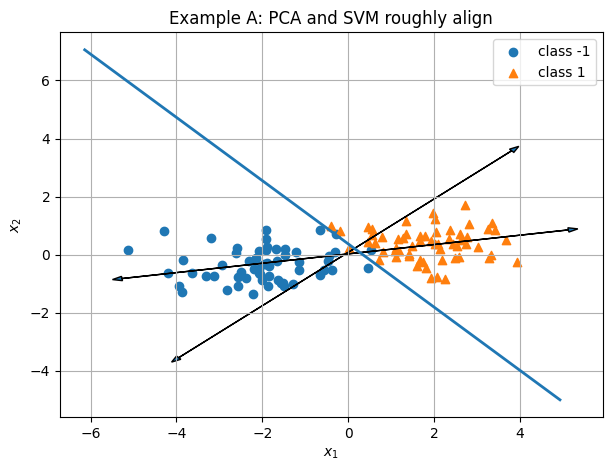

In [10]:
X_a, y_a = make_blobs(n_samples=120, centers=[(-2, -0.4), (2, 0.4)],
                     cluster_std=[(1.0, 0.5), (1.0, 0.5)], random_state=8)
y_a = 2 * y_a - 1

fig, ax = plt.subplots(figsize=(7, 5))
plot_pca_and_svm(X_a, y_a, ax=ax, title='Example A: PCA and SVM roughly align')
plt.show()


### Example B: PCA and SVM strongly disagree

Now each class is elongated in the vertical direction, but the class separation is mostly horizontal.

- PCA follows the direction of largest overall variance, which is mostly vertical.
- SVM focuses on the direction that separates the classes, which is mostly horizontal.


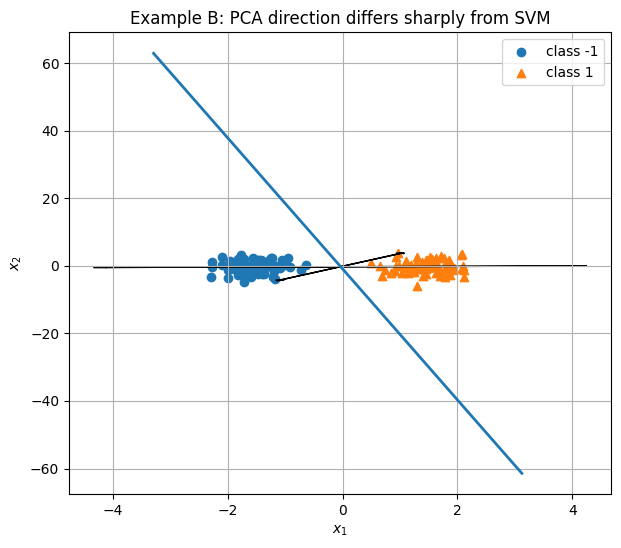

In [11]:
mean_neg = np.array([-1.5, 0.0])
mean_pos = np.array([ 1.5, 0.0])
Sigma = np.array([[0.15, 0.0], [0.0, 3.5]])
X_neg = rng.multivariate_normal(mean_neg, Sigma, size=80)
X_pos = rng.multivariate_normal(mean_pos, Sigma, size=80)
X_b = np.vstack([X_neg, X_pos])
y_b = np.hstack([-np.ones(len(X_neg), dtype=int), np.ones(len(X_pos), dtype=int)])

fig, ax = plt.subplots(figsize=(7, 6))
plot_pca_and_svm(X_b, y_b, ax=ax, title='Example B: PCA direction differs sharply from SVM')
plt.show()


In [12]:
# Compare classification accuracy before and after projection to the first principal component.
pca1 = PCA(n_components=1)
X_b_1d = pca1.fit_transform(X_b)

clf_2d = fit_linear_svm(X_b, y_b, C=1e6)
clf_1d = fit_linear_svm(X_b_1d, y_b, C=1e6)

acc_2d = accuracy_score(y_b, clf_2d.predict(X_b))
acc_1d = accuracy_score(y_b, clf_1d.predict(X_b_1d))

print(f'Linear SVM accuracy on original 2D data   = {acc_2d:.3f}')
print(f'Linear SVM accuracy after PCA to 1D       = {acc_1d:.3f}')


Linear SVM accuracy on original 2D data   = 1.000
Linear SVM accuracy after PCA to 1D       = 0.644


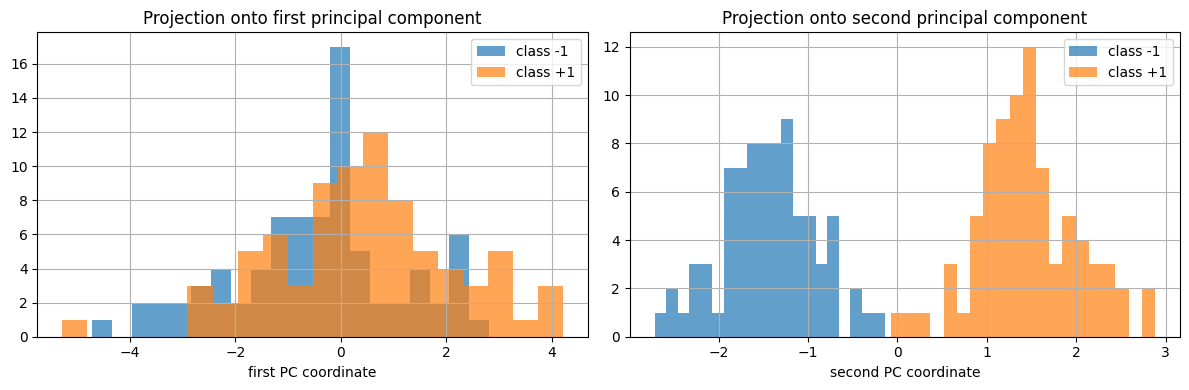

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_b_1d[y_b == -1, 0], bins=20, alpha=0.7, label='class -1')
axes[0].hist(X_b_1d[y_b == 1, 0], bins=20, alpha=0.7, label='class +1')
axes[0].set_title('Projection onto first principal component')
axes[0].set_xlabel('first PC coordinate')
axes[0].legend()

second_pc = PCA(n_components=2).fit(X_b).transform(X_b)[:, 1]
axes[1].hist(second_pc[y_b == -1], bins=20, alpha=0.7, label='class -1')
axes[1].hist(second_pc[y_b == 1], bins=20, alpha=0.7, label='class +1')
axes[1].set_title('Projection onto second principal component')
axes[1].set_xlabel('second PC coordinate')
axes[1].legend()

plt.tight_layout()
plt.show()


The lesson is precise:

- PCA preserves variance, not class separation.
- SVM uses label information and explicitly optimizes separability.
- PCA can be a useful preprocessing step, but it is not a substitute for a classifier.


## 7. Kernel trick

Suppose the classes are not linearly separable in the original input space. We may try to map the input into a higher-dimensional feature space:

$$
\phi : x \mapsto \phi(x).
$$

A linear SVM in feature space has decision function

$$
f(x) = w^\top \phi(x) + b.
$$

From the dual viewpoint, the data appear only through inner products. Therefore we can replace

$$
\phi(x_i)^\top \phi(x_j)
$$

by a kernel function

$$
K(x_i, x_j).
$$

This produces the kernelized decision function

$$
f(x) = \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b.
$$

Typical kernels include:

- **linear**: $K(x,z)=x^\top z$,
- **polynomial**: $K(x,z)=(x^\top z + c)^d$,
- **RBF / Gaussian**: $K(x,z)=\exp(-\gamma\|x-z\|^2)$.


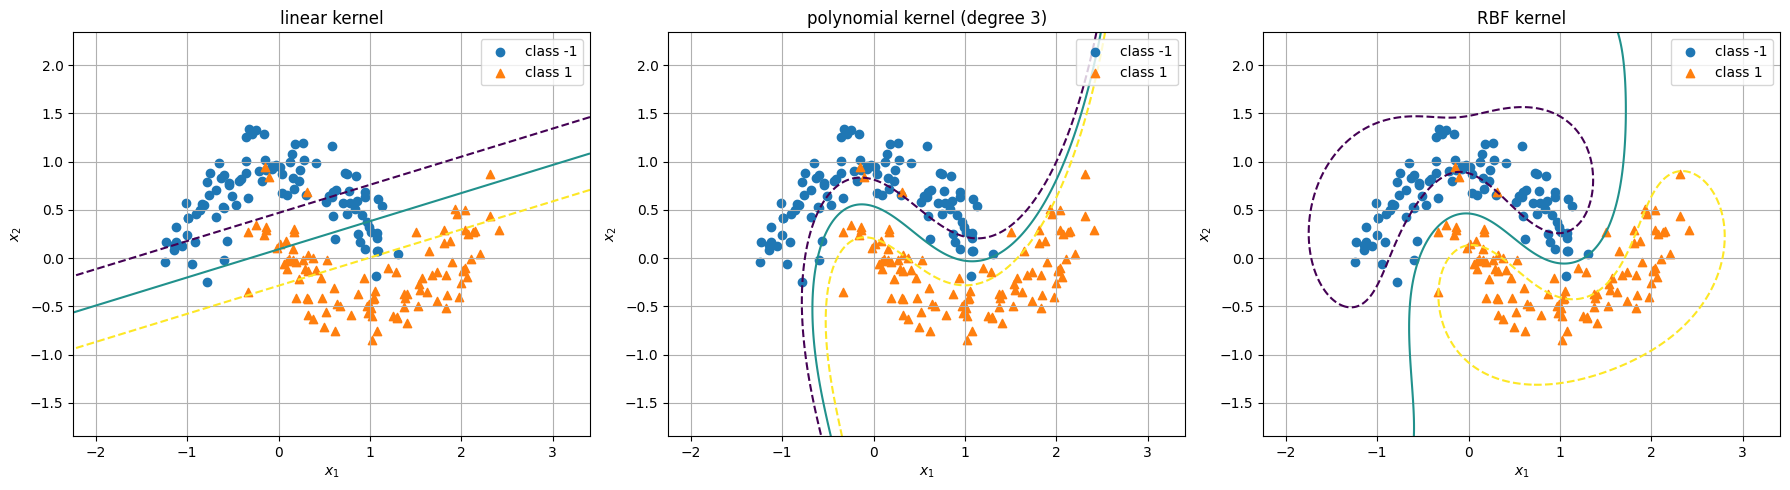

In [14]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.18, random_state=2)
y_moons = 2 * y_moons - 1

models = [
    ('linear kernel', SVC(kernel='linear', C=1.0)),
    ('polynomial kernel (degree 3)', SVC(kernel='poly', degree=3, coef0=1.0, C=1.0)),
    ('RBF kernel', SVC(kernel='rbf', gamma='scale', C=1.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models):
    clf.fit(X_moons, y_moons)
    plot_decision_function(clf, X_moons, y_moons, ax=ax, title=name, show_support=False)
plt.tight_layout()
plt.show()


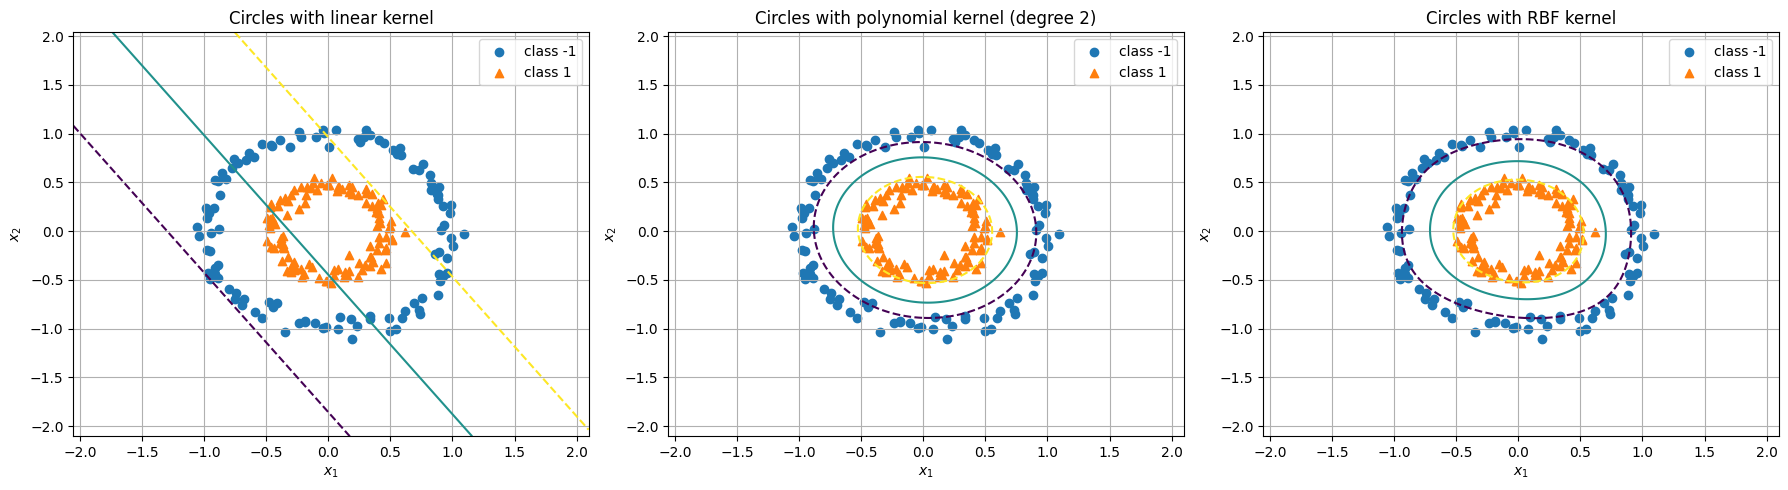

In [15]:
X_circles, y_circles = make_circles(n_samples=220, factor=0.45, noise=0.06, random_state=4)
y_circles = 2 * y_circles - 1

models = [
    ('linear kernel', SVC(kernel='linear', C=1.0)),
    ('polynomial kernel (degree 2)', SVC(kernel='poly', degree=2, coef0=1.0, C=1.0)),
    ('RBF kernel', SVC(kernel='rbf', gamma='scale', C=1.0)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, clf) in zip(axes, models):
    clf.fit(X_circles, y_circles)
    plot_decision_function(clf, X_circles, y_circles, ax=ax, title=f'Circles with {name}', show_support=False)
plt.tight_layout()
plt.show()


### Convexity survives kernelization

Kernel SVM is still a convex optimization problem, provided the kernel matrix

$$
K_{ij} = K(x_i, x_j)
$$

is positive semidefinite. That is why kernel SVM retains the attractive global-optimality structure of ordinary SVM.


## 8. Summary

### What SVM optimizes

SVM searches for a separator with a large margin.  
In the hard-margin case it solves

$$
\min_{w,b} \frac12\|w\|^2
\quad \text{subject to} \quad
y_i(w^\top x_i+b) \ge 1.
$$

### Why optimization matters

This is a convex quadratic program, so the solution is globally optimal.

### Why support vectors matter

The final classifier depends only on training points with nonzero dual coefficients.

### How PCA differs

- PCA: unsupervised, maximizes variance.
- SVM: supervised, maximizes margin.

### Why kernels matter

The dual formulation depends only on inner products, which allows nonlinear decision boundaries through valid kernels.


## 9. Suggested follow-up explorations

1. Replace the synthetic data with a real dataset and compare linear versus RBF SVM.
2. Standardize features and study how the margin changes.
3. Use cross-validation to tune $C$, degree, or RBF bandwidth.
4. Compare SVM with logistic regression on the same data.
5. Explore how many support vectors appear as the overlap between classes increases.
